In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
# 1. Load dataset
data = pd.read_csv("spam_ham_dataset.csv")

In [3]:
# 2. Explore dataset
print("Dataset shape:", data.shape)
print(data.head())
print(data['label_num'].value_counts())

Dataset shape: (5171, 4)
   Unnamed: 0 label                                               text  \
0         605   ham  Subject: enron methanol ; meter # : 988291\r\n...   
1        2349   ham  Subject: hpl nom for january 9 , 2001\r\n( see...   
2        3624   ham  Subject: neon retreat\r\nho ho ho , we ' re ar...   
3        4685  spam  Subject: photoshop , windows , office . cheap ...   
4        2030   ham  Subject: re : indian springs\r\nthis deal is t...   

   label_num  
0          0  
1          0  
2          0  
3          1  
4          0  
label_num
0    3672
1    1499
Name: count, dtype: int64


In [4]:
# 3. Check missing/duplicate values
print("Missing values:\n", data.isnull().sum())
print("Duplicates:", data.duplicated().sum())

Missing values:
 Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64
Duplicates: 0


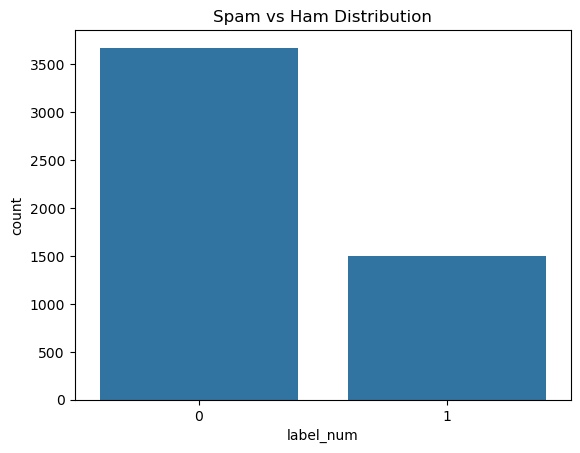

In [5]:
# 4. Visualize class distribution
sns.countplot(x=data['label_num'])
plt.title("Spam vs Ham Distribution")
plt.show()


In [6]:
# 5. Preprocess text (lowercase, remove punctuation/numbers)
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # keep only letters
    return text

data['clean_text'] = data['text'].apply(preprocess)

In [11]:
# Split data
from sklearn.model_selection import train_test_split

X = data['clean_text']   
y = data['label_num']    

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [12]:
# 7. Feature extraction (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
x_train = tfidf.fit_transform(X_train)
x_test = tfidf.transform(X_test)

In [13]:
# Train Naive Bayes model
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(x_train, y_train)


MultinomialNB()

In [14]:
# Evaluate performance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = nb.predict(x_test)

In [16]:
print("Testing Accuracy:", accuracy_score(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Testing Accuracy: 0.9536231884057971

 Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       732
           1       0.92      0.92      0.92       303

    accuracy                           0.95      1035
   macro avg       0.94      0.94      0.94      1035
weighted avg       0.95      0.95      0.95      1035


 Confusion Matrix:
 [[707  25]
 [ 23 280]]


In [17]:
# Test with a custom email
email = ["Hey, Jack what's up dude? Tomorrow please meet me at my home."]
clean_email = tfidf.transform([preprocess(email[0])])
prediction = nb.predict(clean_email)[0]

print("\n Custom Email Prediction:", "Spam" if prediction == 1 else "Not Spam")



 Custom Email Prediction: Not Spam
